# MLA 与 KV Cache 压缩

> Part 2 的架构演进一节里，我们走完了"归一化层、激活函数、位置编码、注意力"这条升级路径，把 MiniGPT 的零件逐个换成现代版本。注意力那部分提到了 GQA——让多个 query 头共享一组 K、V，缩小 KV Cache。
>
> 这一节继续追注意力这条线。DeepSeek-V2 提出的 Multi-head Latent Attention（MLA）走的是另一条路：把 K、V 联合投影到一个低维 latent 向量，推理时只缓存这个 latent。先看清 KV Cache 在长上下文下到底吃多少显存，再依次过 MHA / GQA / MQA 各自牺牲了什么，最后从零实现一个简化版 MLA，量出它的 cache 节省比例。

KV Cache 是 decoder-only 模型推理时存下的所有历史 token 的 K 和 V。模型生成第 N 个 token 时，新 token 通过 attention 看到 N-1 个历史 token——用 query 和历史的 key 算分数，再用分数加权历史的 value。如果每次都重算历史的 K、V，开销随序列长度平方增长；缓存下来后，每次只需算新 token 的 K、V 一份，复杂度降为线性。

代价是显存。一个 7B 模型在 32K 上下文下，KV Cache 大约占 16 GB；到 128K，KV Cache 接近 64 GB——一张 A100 80GB 单卡装下模型加 KV Cache 都吃力。GQA 让多头共享 K、V，能省几倍；MLA 用 latent 压缩能省更多，且基本不掉能力。这两条路具体在做什么，就是这一节的主线。

## 1. KV Cache 的代价：手算一笔账

先把账算清楚。给定一个模型配置，KV Cache 占多少显存？

每个 token 在每一层都要存一对 (K, V) 向量。K 和 V 的维度都是 `num_heads × head_dim`。所以：

```
每 token 每层 K+V 元素数 = num_heads × head_dim × 2
全部 KV Cache 元素数     = seq_len × num_layers × num_heads × head_dim × 2
字节数                  = 元素数 × bytes_per_element
```

下面用 Llama-7B 的具体配置算一遍。

In [1]:
# 手算 KV Cache 占用：Llama-7B 的具体数字

hidden_size = 4096
num_layers = 32
num_heads = 32
head_dim = hidden_size // num_heads  # 128
seq_len = 32768  # 32K 上下文
bytes_per_element = 2  # FP16

# MHA：每个 token 每层存 num_heads 对 (K, V)
elements_per_token_per_layer = num_heads * head_dim * 2  # 乘 2 是因为 K 和 V 各一份
total_elements = seq_len * num_layers * elements_per_token_per_layer
total_bytes = total_elements * bytes_per_element
total_gb = total_bytes / (1024 ** 3)

print(f"模型: hidden={hidden_size}, layers={num_layers}, heads={num_heads}, head_dim={head_dim}")
print(f"上下文: {seq_len} tokens, dtype=FP16")
print()
print(f"每 token 每层 K+V 元素数: {elements_per_token_per_layer}")
print(f"全部 KV Cache 元素数: {total_elements:,}")
print(f"FP16 字节数: {total_bytes:,}")
print(f"KV Cache 总占用: {total_gb:.2f} GB")
print()
print(f"对比：Llama-7B 权重本身约 13 GB（FP16）")
print(f"关键观察：32K 上下文下，KV Cache 已经超过模型权重本身")

模型: hidden=4096, layers=32, heads=32, head_dim=128
上下文: 32768 tokens, dtype=FP16

每 token 每层 K+V 元素数: 8192
全部 KV Cache 元素数: 8,589,934,592
FP16 字节数: 17,179,869,184
KV Cache 总占用: 16.00 GB

对比：Llama-7B 权重本身约 13 GB（FP16）
关键观察：32K 上下文下，KV Cache 已经超过模型权重本身


## 2. MHA / GQA / MQA：减少 KV 头数的传统思路

减小 KV Cache 的传统思路是减少 KV 头的数量。三代方案演进如下：

| 方案 | num_kv_heads | 每 token 每层 K+V | 相对 MHA | 代表模型 |
|:---|:---|:---|:---|:---|
| MHA | = num_heads | num_heads × head_dim × 2 | 1.0× | 原始 Transformer, GPT-2 |
| GQA | num_heads / G | (num_heads / G) × head_dim × 2 | 1/G × | Llama 2/3, Qwen, Mistral |
| MQA | 1 | head_dim × 2 | 1/num_heads × | PaLM, Falcon |

直觉上：原本每个 query 头都有自己的 K、V；GQA 让一组 query 头共用一份；MQA 让所有 query 头共用同一份。共享越多，KV Cache 越小，但 query 头之间能用的信息差异也越小。

代价是模型能力。共享太多会让 attention 多样性下降——所有 query 头看到几乎相同的 K、V，本质上是把多头退化成接近单头。Llama 2 70B 用 GQA（8 组），Llama 3 8B 用 GQA（4 组），是工程上权衡出的常见配置。

下面用代码实现三种方案的 cache 大小对比。

In [2]:
# 三种注意力的 KV Cache 对比

def kv_cache_elements(num_heads, head_dim, num_layers, seq_len, num_kv_heads):
    """算 KV Cache 元素数"""
    per_token_per_layer = num_kv_heads * head_dim * 2  # K + V
    return seq_len * num_layers * per_token_per_layer

# Llama-7B 配置
num_heads = 32
head_dim = 128
num_layers = 32
seq_len = 32768
bytes_per_element = 2

configs = [
    ("MHA",    num_heads),
    ("GQA-8",  num_heads // 8),  # 4 个 KV 头
    ("GQA-4",  num_heads // 4),  # 8 个 KV 头
    ("MQA",    1),
]

print(f"{'方案':<10} {'KV头数':<10} {'元素数':<20} {'GB':<10} {'相对MHA':<10}")
print("-" * 60)
base = None
for name, n_kv in configs:
    elems = kv_cache_elements(num_heads, head_dim, num_layers, seq_len, n_kv)
    gb = elems * bytes_per_element / (1024 ** 3)
    if base is None:
        base = gb
    print(f"{name:<10} {n_kv:<10} {elems:<20,} {gb:<10.2f} {gb/base:.2f}×")

print()
print("关键观察：MQA 把 KV Cache 压到 1/32，但代价是 attention 多样性显著下降")
print("GQA 是常见折中，Llama 系列从 Llama 2 70B 开始采用")

方案         KV头数       元素数                  GB         相对MHA     
------------------------------------------------------------
MHA        32         8,589,934,592        16.00      1.00×
GQA-8      4          1,073,741,824        2.00       0.12×
GQA-4      8          2,147,483,648        4.00       0.25×
MQA        1          268,435,456          0.50       0.03×

关键观察：MQA 把 KV Cache 压到 1/32，但代价是 attention 多样性显著下降
GQA 是常见折中，Llama 系列从 Llama 2 70B 开始采用


## 3. MLA 的核心思想：latent 压缩

GQA / MQA 通过减少 KV 头数压缩 cache，本质上是在「头数」这个维度做文章。MLA 不动头数，而是换了一个角度：把 K、V 投影到一个低维 latent 向量上，推理时只缓存这个 latent。

具体来说，标准 attention 里，hidden state `h` 经过两个投影矩阵得到 `K = W_K · h` 和 `V = W_V · h`，二者维度都是 `num_heads × head_dim`。MLA 把这一步改成：

```
c = W_DK · h       # down-project 到低维 latent（d_c << num_heads × head_dim）
K = W_UK · c       # up-project 回多头空间
V = W_UV · c       # 同样从 c 上投影
```

推理时只缓存 `c`。因为 `d_c` 远小于 `num_heads × head_dim`，cache 大幅缩小。模型能力基本不掉的原因是：`W_DK` 和 `W_UK / W_UV` 是训练时学到的，模型本质上是在 latent 空间做信息瓶颈，把"必要的"信息压缩进 `c` 里，主动丢掉冗余。

下面用一个具体小例子手算 latent 压缩的比例。

In [3]:
# MLA 的 latent 压缩：手算具体数字

# 参考 DeepSeek-V2 的尺度，对比 MHA 和 MLA 每 token 每层的 cache
num_heads = 128
head_dim = 128
mha_per_token_per_layer = num_heads * head_dim * 2  # K + V
print(f"MHA 每 token 每层 K+V 元素数: {mha_per_token_per_layer}")
print(f"  = {num_heads} heads × {head_dim} dim × 2 (K+V)")

# MLA：用一个低维 latent c（d_c）同时承载 K 和 V 的信息
# DeepSeek-V2 的 d_c = 512
d_c = 512
mla_per_token_per_layer = d_c  # MLA 只缓存 c，K 和 V 都从 c 上投影出来
print(f"\nMLA 每 token 每层 latent 元素数: {mla_per_token_per_layer}")
print(f"  = d_c = {d_c}（K 和 V 共用同一个 latent）")

compression = mha_per_token_per_layer / mla_per_token_per_layer
saving = (1 - mla_per_token_per_layer / mha_per_token_per_layer) * 100
print(f"\n压缩比: {compression:.1f}×")
print(f"节省: {saving:.1f}%")
print()
print(f"关键观察：MLA 把每 token 每层的 cache 从 {mha_per_token_per_layer} 个元素")
print(f"压到 {mla_per_token_per_layer} 个元素，节省 {saving:.0f}%")

MHA 每 token 每层 K+V 元素数: 32768
  = 128 heads × 128 dim × 2 (K+V)

MLA 每 token 每层 latent 元素数: 512
  = d_c = 512（K 和 V 共用同一个 latent）

压缩比: 64.0×
节省: 98.4%

关键观察：MLA 把每 token 每层的 cache 从 32768 个元素
压到 512 个元素，节省 98%


## 4. 从零实现简化 MLA

下面写一个教学版的 MLA。简化处理：暂时不加 RoPE（RoPE 和 MLA 的冲突留到第 6 节展开），只展示 latent 压缩的核心机制。

核心数据流：`x → c = W_DK(x) → K = W_UK(c), V = W_UV(c)`。推理时只需要保存 `c`，K 和 V 在需要时再投影出来。

In [4]:
# 简化版 MLA：展示 latent 压缩的核心机制
# 暂时不加 RoPE（第 6 节单独讲）

import torch
import torch.nn as nn

class SimpleMLA(nn.Module):
    """教学版 MLA，展示 latent 压缩机制

    参数:
        d_model: 模型 hidden 维度
        num_heads: query 头数
        head_dim: 每个头的维度
        d_c: latent 维度（KV 共用）
    """
    def __init__(self, d_model, num_heads, head_dim, d_c):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.d_c = d_c

        # query 路径：标准投影
        self.W_Q = nn.Linear(d_model, num_heads * head_dim, bias=False)

        # KV 路径：先 down-project 到 latent c，再 up-project 回 K/V
        self.W_DK = nn.Linear(d_model, d_c, bias=False)                   # down
        self.W_UK = nn.Linear(d_c, num_heads * head_dim, bias=False)      # up to K
        self.W_UV = nn.Linear(d_c, num_heads * head_dim, bias=False)      # up to V

        # 输出投影
        self.W_O = nn.Linear(num_heads * head_dim, d_model, bias=False)

    def forward(self, x):
        """
        x: [batch, seq_len, d_model]
        返回: (output [batch, seq_len, d_model], latent c [batch, seq_len, d_c])
        """
        B, S, D = x.shape

        # Q 路径：标准投影
        Q = self.W_Q(x).view(B, S, self.num_heads, self.head_dim)

        # KV 路径：经过 latent c
        c = self.W_DK(x)  # [B, S, d_c] —— 这就是要缓存的 latent
        K = self.W_UK(c).view(B, S, self.num_heads, self.head_dim)
        V = self.W_UV(c).view(B, S, self.num_heads, self.head_dim)

        # 标准 attention 计算（简化版，不加 mask）
        Q = Q.transpose(1, 2)  # [B, num_heads, S, head_dim]
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        scores = Q @ K.transpose(-1, -2) / (self.head_dim ** 0.5)
        attn = scores.softmax(dim=-1)
        out = attn @ V  # [B, num_heads, S, head_dim]

        out = out.transpose(1, 2).reshape(B, S, self.num_heads * self.head_dim)
        return self.W_O(out), c  # 同时返回 latent，方便后面量 cache


# 测试
torch.manual_seed(42)
d_model = 64
num_heads = 4
head_dim = 16
d_c = 16  # latent 维度

mla = SimpleMLA(d_model, num_heads, head_dim, d_c)
x = torch.randn(1, 10, d_model)
out, c = mla(x)
print(f"输入 shape: {x.shape}")
print(f"输出 shape: {out.shape}")
print(f"latent c shape: {c.shape}")
print()
mha_elems = num_heads * head_dim * 2
print(f"标准 MHA 每 token 每层要缓存 K+V = {mha_elems} 个元素")
print(f"MLA 每 token 每层只缓存 c = {d_c} 个元素")
print(f"压缩比: {mha_elems / d_c:.1f}×")

输入 shape: torch.Size([1, 10, 64])
输出 shape: torch.Size([1, 10, 64])
latent c shape: torch.Size([1, 10, 16])

标准 MHA 每 token 每层要缓存 K+V = 128 个元素
MLA 每 token 每层只缓存 c = 16 个元素
压缩比: 8.0×


## 5. KV Cache 实测对比

把 MHA / GQA / MLA 放到同一个图上，看 cache 随上下文长度的增长。配置参考 DeepSeek-V2 的尺度：`num_heads=128, head_dim=128, num_layers=60, d_c=512`。这是工业级模型的实际配置。

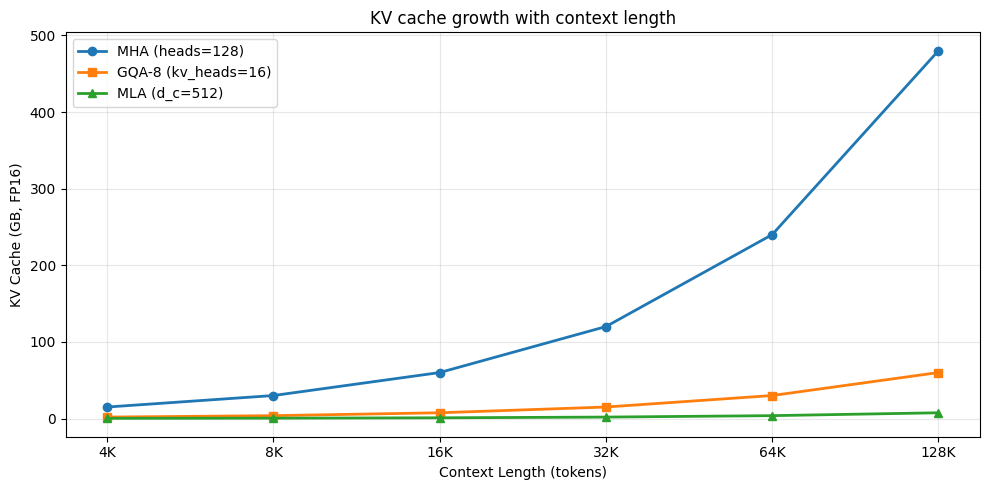

128K 上下文下的 KV Cache：
  MHA:      480.0 GB
  GQA-8:     60.0 GB  (8.0× 压缩)
  MLA:        7.5 GB  (64.0× 压缩)

关键观察：在长上下文场景，MLA 比 GQA 又多省了一个数量级


In [5]:
# 同一个 toy 模型跑 MHA / GQA / MLA，量 cache 随上下文长度的变化

import matplotlib.pyplot as plt

def mha_cache(num_heads, head_dim, num_layers, seq_len):
    """标准 MHA 的 KV cache 元素数"""
    return seq_len * num_layers * num_heads * head_dim * 2

def gqa_cache(num_heads, head_dim, num_layers, seq_len, num_groups):
    """GQA 的 KV cache 元素数"""
    num_kv_heads = num_heads // num_groups
    return seq_len * num_layers * num_kv_heads * head_dim * 2

def mla_cache(d_c, num_layers, seq_len):
    """MLA 的 KV cache 元素数（暂不计 decoupled RoPE 那一小部分）"""
    return seq_len * num_layers * d_c

# 模型配置（参考 DeepSeek-V2 尺度）
num_layers = 60
num_heads = 128
head_dim = 128
d_c = 512  # MLA latent

seq_lens = [4096, 8192, 16384, 32768, 65536, 131072]

bytes_per_elem = 2  # FP16
mha_sizes = [mha_cache(num_heads, head_dim, num_layers, s) * bytes_per_elem / (1024**3) for s in seq_lens]
gqa_sizes = [gqa_cache(num_heads, head_dim, num_layers, s, 8) * bytes_per_elem / (1024**3) for s in seq_lens]
mla_sizes = [mla_cache(d_c, num_layers, s) * bytes_per_elem / (1024**3) for s in seq_lens]

plt.figure(figsize=(10, 5))
plt.plot(seq_lens, mha_sizes, 'o-', label=f'MHA (heads={num_heads})', linewidth=2)
plt.plot(seq_lens, gqa_sizes, 's-', label=f'GQA-8 (kv_heads={num_heads//8})', linewidth=2)
plt.plot(seq_lens, mla_sizes, '^-', label=f'MLA (d_c={d_c})', linewidth=2)
plt.xlabel('Context Length (tokens)')
plt.ylabel('KV Cache (GB, FP16)')
plt.title('KV cache growth with context length')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.xticks(seq_lens, [f'{s//1024}K' for s in seq_lens])
plt.tight_layout()
plt.show()

# 打印 128K 下的对比
print(f"128K 上下文下的 KV Cache：")
print(f"  MHA:    {mha_sizes[-1]:7.1f} GB")
print(f"  GQA-8:  {gqa_sizes[-1]:7.1f} GB  ({mha_sizes[-1]/gqa_sizes[-1]:.1f}× 压缩)")
print(f"  MLA:    {mla_sizes[-1]:7.1f} GB  ({mha_sizes[-1]/mla_sizes[-1]:.1f}× 压缩)")
print()
print("关键观察：在长上下文场景，MLA 比 GQA 又多省了一个数量级")

## 6. RoPE 与 MLA 的冲突

MLA 的核心机制是 latent 压缩：缓存 `c`，需要时投影回 K、V。但有一个隐藏的麻烦——RoPE。

回忆 Part 1 的位置编码一节：RoPE 是作用在 Q 和 K 上的旋转，让点积只依赖于相对位置。具体来说，RoPE 对 K 的每一对相邻维度做不同角度的旋转，这个操作**不能写成 `K_rotated = R · K` 的形式**（R 是固定矩阵）——它依赖于 K 的具体维度排列。

MLA 的关键优势是推理时只缓存 `c`，`K = W_UK · c` 在需要时再算。但 RoPE 要作用在 K 上，意味着得先算出 K 才能加 RoPE——这就违背了「只缓存 c」的初衷。如果推理时为了加 RoPE 把 K 算出来，那 MLA 的压缩优势就消失了。

DeepSeek-V2 的解决方案叫 **decoupled RoPE**：把 RoPE 部分单独拆出来，用一个独立的小维度（`d_r`，比如 64）单独算 RoPE，不经过 latent 压缩。最终 K 拼成两部分：`[W_UK · c ; RoPE(W_R · x)]`——前半部分走 latent，后半部分走 RoPE 旁路。推理时除了缓存 `c`，还要缓存 RoPE 旁路的部分。

这部分细节较深。对这一节来说，记住「RoPE 不能直接套在 MLA 上」和「DeepSeek 用 decoupled RoPE 绕开」这两点就够了。

In [6]:
# 演示 RoPE 与 MLA 的冲突，以及 decoupled RoPE 的结构

# 在 MLA 里：K = W_UK · c
# 但 RoPE 要在算出 K 之后再加，意味着推理时必须算出 K——违背"只缓存 c"的初衷

# DeepSeek 的解法：decoupled RoPE
#   把 K 拆成两部分，分别处理：
#     Part 1: W_UK · c         (主部分，从 latent 投影，无 RoPE)
#     Part 2: RoPE(W_R · x)    (RoPE 旁路，直接从 x 投影，单独加 RoPE)
#   最终 K = concat([Part 1, Part 2])

# DeepSeek-V2 的具体维度（论文报告值）
num_heads = 128
head_dim = 128
d_c = 512       # latent c 的维度
d_r = 64        # decoupled RoPE 部分的维度（每头）

mha_per_token_per_layer = num_heads * head_dim * 2  # K + V
mla_per_token_per_layer = d_c + num_heads * d_r     # latent c + RoPE 旁路（每头一份）

print("DeepSeek-V2 的 MLA 实际缓存结构：")
print(f"  latent c:           {d_c:5d} 维（K 和 V 共用）")
print(f"  RoPE 旁路:          {num_heads} heads × {d_r} dim = {num_heads * d_r:5d} 维")
print(f"  MLA 每 token 每层:  {mla_per_token_per_layer:5d} 元素")
print()
print(f"对比 MHA 每 token 每层: {mha_per_token_per_layer} 元素")
print(f"压缩比: {mha_per_token_per_layer / mla_per_token_per_layer:.1f}×")
print()
print("关键观察：RoPE 旁路只占一小部分（这里 8192 维），大头还是 latent c（512 维）")
print("即使加上 RoPE 旁路，MLA 仍然比 MHA 压缩了一个数量级")

DeepSeek-V2 的 MLA 实际缓存结构：
  latent c:             512 维（K 和 V 共用）
  RoPE 旁路:          128 heads × 64 dim =  8192 维
  MLA 每 token 每层:   8704 元素

对比 MHA 每 token 每层: 32768 元素
压缩比: 3.8×

关键观察：RoPE 旁路只占一小部分（这里 8192 维），大头还是 latent c（512 维）
即使加上 RoPE 旁路，MLA 仍然比 MHA 压缩了一个数量级


## 7. MLA 在 DeepSeek-V2 / V3 / Kimi K2 的工程收益

MLA 不是教学玩具，已经被多个生产模型采用。下表是几个代表性模型的 MLA 配置：

| 模型 | num_heads | head_dim | d_c (latent) | d_r (RoPE 旁路) | 备注 |
|:---|:---|:---|:---|:---|:---|
| DeepSeek-V2 | 128 | 128 | 512 | 64 | MLA 首次大规模落地 |
| DeepSeek-V3 | 128 | 128 | 512 | 64 | 沿用 V2 配置 |
| Kimi K2 | 64 | 192 | 512 | 64 | 调整头数和 head_dim |

MLA 的代价是计算变多。MHA 一次矩阵乘得到 K，MLA 要两次（先 `W_DK` 再 `W_UK`），训练时 FLOPs 增加。但推理时由于 cache 大幅缩小，总 wall-clock 时间在长上下文场景反而更快——显存带宽是推理的主要瓶颈，cache 越小，每生成一个 token 需要读的显存越少。

实际部署还要看推理框架是否原生支持 MLA。vLLM、SGLang、TensorRT-LLM 都已经加入 MLA 支持，但比标准 MHA / GQA 的支持要新，工程成熟度仍在追赶。

## 小结

- [ ] KV Cache 是 decoder-only 模型推理时存的所有历史 token 的 K、V，随上下文长度线性增长
- [ ] 7B 模型在 32K 上下文下 KV Cache 约 16 GB，已经接近模型权重本身的大小
- [ ] GQA / MQA 通过减少 KV 头数压缩 cache，代价是 attention 多样性下降
- [ ] MLA 把 K、V 联合投影到低维 latent，推理时只缓存 latent，压缩比远高于 GQA
- [ ] MLA 推理时只缓存 latent `c`，需要时投影回 K、V；机制上是信息瓶颈
- [ ] RoPE 不能直接套在 MLA 上，DeepSeek 用 decoupled RoPE 解决：主部分走 latent，小部分走 RoPE 旁路
- [ ] DeepSeek-V2 / V3 / Kimi K2 都采用 MLA，cache 压缩一个数量级，长上下文场景推理速度更快

参考：[DeepSeek-V2](https://arxiv.org/abs/2405.04434)、[DeepSeek-V3](https://arxiv.org/abs/2412.19437)、[Kimi K2](https://arxiv.org/abs/2507.20534)、[GQA 原论文](https://arxiv.org/abs/2305.13245)。

## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：KV Cache 大小计算**

给定模型配置：`hidden_size=4096, num_layers=32, num_heads=32, head_dim=128, seq_len=16384, dtype=FP16`。算出 MHA 下的 KV Cache 占用多少 GB。

小提示：每 token 每层 K+V 元素数 = `num_heads × head_dim × 2`。总元素数 = `seq_len × num_layers × 该值`。字节数 = 元素数 × 2。GB = 字节数 / 1024³。

In [7]:
# 作业 1：KV Cache 大小计算

hidden_size = 4096
num_layers = 32
num_heads = 32
head_dim = hidden_size // num_heads
seq_len = 16384
bytes_per_element = 2  # FP16

# TODO: 填入计算
elements_per_token_per_layer = num_heads * head_dim * 2
total_elements = seq_len * num_layers * elements_per_token_per_layer
total_gb = total_elements * bytes_per_element / (1024**3)

# 验证
assert elements_per_token_per_layer is not None, "请先计算 elements_per_token_per_layer"
assert total_elements is not None, "请先计算 total_elements"
assert total_gb is not None, "请先计算 total_gb"

expected_eptpl = 32 * 128 * 2
expected_total = 16384 * 32 * expected_eptpl
expected_gb = expected_total * 2 / (1024**3)

assert elements_per_token_per_layer == expected_eptpl
assert total_elements == expected_total
assert abs(total_gb - expected_gb) < 0.01, f"应为 {expected_gb:.2f} GB"

print(f"✅ 作业 1 通过")
print(f"   每 token 每层 K+V: {elements_per_token_per_layer} 元素")
print(f"   总元素数: {total_elements:,}")
print(f"   KV Cache 总占用: {total_gb:.2f} GB")

✅ 作业 1 通过
   每 token 每层 K+V: 8192 元素
   总元素数: 4,294,967,296
   KV Cache 总占用: 8.00 GB


**作业 2：MLA 的 latent 压缩比**

给定 `num_heads=32, head_dim=128, d_c=256`。算出 MLA 相对 MHA 的 cache 压缩比。

小提示：MHA 每 token 每层 cache = `num_heads × head_dim × 2`（K+V）。MLA 每 token 每层 cache = `d_c`。

In [8]:
# 作业 2：MLA 的 latent 压缩比

num_heads = 32
head_dim = 128
d_c = 256

# TODO: 填入计算
mha_cache_per_token = num_heads * head_dim * 2
mla_cache_per_token = d_c
compression_ratio = mla_cache_per_token / mha_cache_per_token

assert mha_cache_per_token is not None, "请先计算 mha_cache_per_token"
assert mla_cache_per_token is not None, "请先计算 mla_cache_per_token"
assert compression_ratio is not None, "请先计算 compression_ratio"

expected_mha = 32 * 128 * 2
expected_mla = 256
expected_ratio = expected_mla / expected_mha

assert mha_cache_per_token == expected_mha
assert mla_cache_per_token == expected_mla
assert abs(compression_ratio - expected_ratio) < 0.001

print(f"✅ 作业 2 通过")
print(f"   MHA 每 token 每层: {mha_cache_per_token} 元素")
print(f"   MLA 每 token 每层: {mla_cache_per_token} 元素")
print(f"   MLA cache 是 MHA 的 {compression_ratio:.4f}")
print(f"   相当于压缩 {1/compression_ratio:.1f}×，节省 {(1-compression_ratio)*100:.1f}%")

✅ 作业 2 通过
   MHA 每 token 每层: 8192 元素
   MLA 每 token 每层: 256 元素
   MLA cache 是 MHA 的 0.0312
   相当于压缩 32.0×，节省 96.9%


**作业 3：补全简化 MLA 的 forward**

下面的 `SimpleMLA` 类省略了 forward 里的 latent c 计算和 K、V 投影步骤。补全这三行，让 assert 通过。

小提示：参考第 4 节的实现。`c = self.W_DK(x)`，然后 `K = self.W_UK(c).view(...).transpose(1, 2)`，V 同理。

In [9]:
# 作业 3：补全简化 MLA 的 forward

import torch
import torch.nn as nn

class SimpleMLA(nn.Module):
    def __init__(self, d_model, num_heads, head_dim, d_c):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.d_c = d_c
        self.W_Q = nn.Linear(d_model, num_heads * head_dim, bias=False)
        self.W_DK = nn.Linear(d_model, d_c, bias=False)
        self.W_UK = nn.Linear(d_c, num_heads * head_dim, bias=False)
        self.W_UV = nn.Linear(d_c, num_heads * head_dim, bias=False)
        self.W_O = nn.Linear(num_heads * head_dim, d_model, bias=False)

    def forward(self, x):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.head_dim).transpose(1, 2)

        # TODO: 补全下面三行
        c = self.W_DK(x)
        K = self.W_UK(c).view(B, S, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.W_UV(c).view(B, S, self.num_heads, self.head_dim).transpose(1, 2)

        scores = Q @ K.transpose(-1, -2) / (self.head_dim ** 0.5)
        attn = scores.softmax(dim=-1)
        out = attn @ V
        out = out.transpose(1, 2).reshape(B, S, self.num_heads * self.head_dim)
        return self.W_O(out)

# 验证
torch.manual_seed(42)
mla = SimpleMLA(d_model=64, num_heads=4, head_dim=16, d_c=16)
x = torch.randn(1, 10, 64)
out = mla(x)

# 如果 c/K/V 没补全，forward 会在 Q @ K.transpose 时报错（K 是 None）
# 所以只要能算出 out 并且 shape 正确，就说明 forward 里的 c/K/V 都补对了
assert out.shape == (1, 10, 64), f"输出 shape 应为 (1, 10, 64)，实际 {out.shape}"
assert torch.isfinite(out).all(), "输出包含 NaN 或 Inf，可能 K/V 投影写错了"

print(f"✅ 作业 3 通过")
print(f"   输入 shape:  {x.shape}")
print(f"   输出 shape:  {out.shape}")
print(f"   MLA 的核心是 latent 压缩：每 token 每层只缓存 {mla.d_c} 维 latent")

✅ 作业 3 通过
   输入 shape:  torch.Size([1, 10, 64])
   输出 shape:  torch.Size([1, 10, 64])
   MLA 的核心是 latent 压缩：每 token 每层只缓存 16 维 latent
